## Overview

The Stommel (1961) model tracks two state variables — the pole-to-equator **temperature contrast** `T` and **salinity contrast** `S` — and uses them to compute an overturning circulation strength `q`. Both variables are dimensionless in the default parameter set.

The diagnostic `q` is the key output: positive values indicate thermally-driven (on) circulation; negative values indicate haline-driven (reversed) circulation.

### Equations

$$
q = k(\alpha T - \beta S)
$$

$$
\frac{dT}{dt} = -\lambda_T (T - T^*) - |q|\, T
$$

$$
\frac{dS}{dt} = E - \lambda_S (S - S^*) - |q|\, S
$$

The restoring terms pull `T` and `S` toward their equatorial references. The advective terms `|q|T` and `|q|S` represent overturning transport. `E` is a net freshwater flux (evaporation minus precipitation).

### Parameters

| Name | Description | Default |
|------|-------------|---------|
| `alpha` | Thermal expansion coefficient | 1.0 |
| `beta` | Haline contraction coefficient | 1.0 |
| `k` | Hydraulic constant (sensitivity of `q` to density contrast) | 1.0 |
| `E` | Net evaporation-minus-precipitation freshwater flux | 0.0 |
| `lambda_T` | Thermal restoring rate | 1.0 |
| `lambda_S` | Saline restoring rate | 1.0 |
| `T_star` | Equilibrium temperature contrast | 1.0 |
| `S_star` | Equilibrium salinity contrast | 0.0 |

All parameters accept a `float`, a callable `(t)` / `(t, state)`, or a `cc.Forcing` object. External forcings are attached after construction via `register_forcing` — see the Forcing section below.



## Basic run

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.stommel import Stommel

model = Stommel(E=0.3, T_star=1.0, S_star=0.0)
output = model.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')

State variables and the overturning diagnostic are accessed directly from the output object:

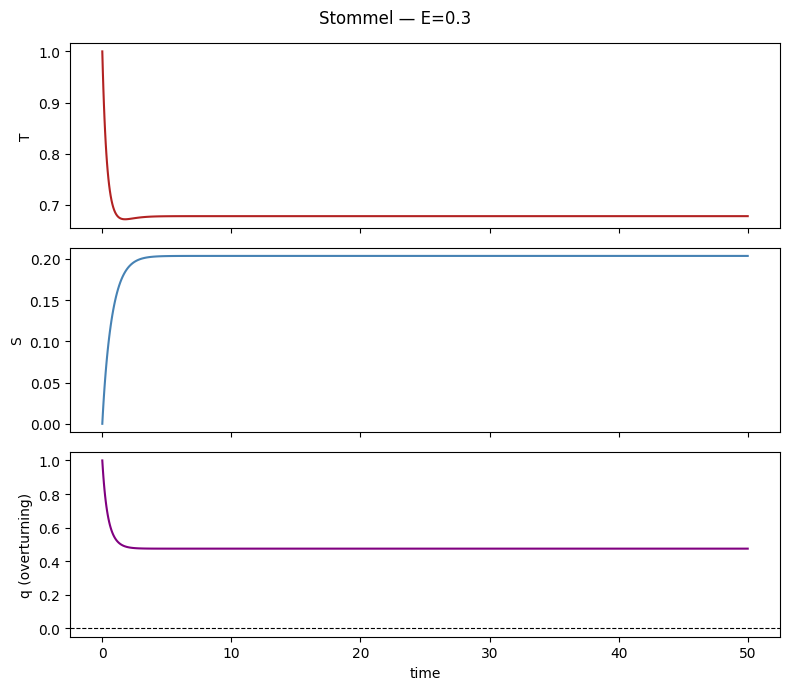

In [2]:
T = output.state_variables['T']
S = output.state_variables['S']
q = output.diagnostic_variables['q']
time = output.time

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
axes[0].plot(time, T, color='firebrick');  axes[0].set_ylabel('T')
axes[1].plot(time, S, color='steelblue'); axes[1].set_ylabel('S')
axes[2].plot(time, q, color='purple')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('q (overturning)'); axes[2].set_xlabel('time')
fig.suptitle('Stommel — E=0.3'); plt.tight_layout(); plt.show()

**Figure.** Default run ($E=0.3$, $T^*=1$). Temperature contrast $T$ equilibrates quickly (fast restoring). Salinity contrast $S$ evolves more slowly under the specified freshwater exchange. Overturning $q$ starts positive (temperature-driven, TH mode) and settles to a steady value — the system remains in the thermally-direct circulation state for these parameters.

## Forcing

Forcings are attached after construction using `register_forcing`. There are two meaningfully different places to attach a freshwater forcing in this model, with different physical interpretations.

First, build the forcing object. `cc.Forcing` accepts a callable, an array with a time axis, or a sequence of composable `Hold`, `Ramp`, and `Harmonic` elements:

In [3]:
fw_forcing = cc.Forcing.from_sequence([
    cc.forcing.Hold(duration=10, value=0.0),
    cc.forcing.Ramp(duration=5,  y0=0.0, yf=0.5),
    cc.forcing.Hold(duration=15, value=0.5),
    cc.forcing.Ramp(duration=5,  y0=0.5, yf=0.0),
    cc.forcing.Hold(duration=15, value=0.0),
])

Always plot the forcing first so the signal is explicit before running any model:

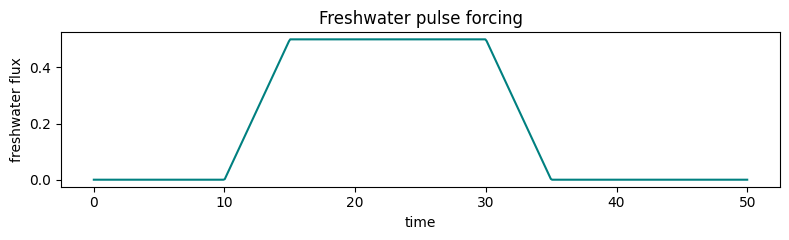

In [4]:
t_plot = np.linspace(0, 50, 500)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_plot, [fw_forcing.get_forcing(t) for t in t_plot], color='teal')
ax.set_xlabel('time'); ax.set_ylabel('freshwater flux'); ax.set_title('Freshwater pulse forcing')
plt.tight_layout(); plt.show()

### Approach 1: parameter replacement on `E`

`register_forcing('E', forcing_obj)` replaces the `E` parameter entirely with the forcing value at each timestep. This is the natural physical interpretation: the forcing *is* the freshwater flux. Any value of `E` set at construction is overridden during integration.

In [5]:
m_E = Stommel(E=0.0, T_star=1.0, S_star=0.0)
m_E.register_forcing('E', fw_forcing)    # attachment_style='replacement', timing='pre' by default
out_E = m_E.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')

### Approach 2: additive forcing on state variable `S`

`register_forcing('S', forcing_obj, 'additive', timing='pre')` adds the forcing value to `dS/dt` inside the right-hand side at each function evaluation. This is a perturbation on top of whatever `E` is already doing.

In [6]:
m_S = Stommel(E=0.0, T_star=1.0, S_star=0.0)
m_S.register_forcing('S', fw_forcing, 'additive', timing='pre')
out_S = m_S.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')

### Comparing the two approaches

When `E=0` at construction, both approaches are **mathematically equivalent**: replacing `E` with `F(t)` gives `dS/dt = F(t) - ...`, and adding `F(t)` to `dS/dt` with `E=0` gives the same expression.

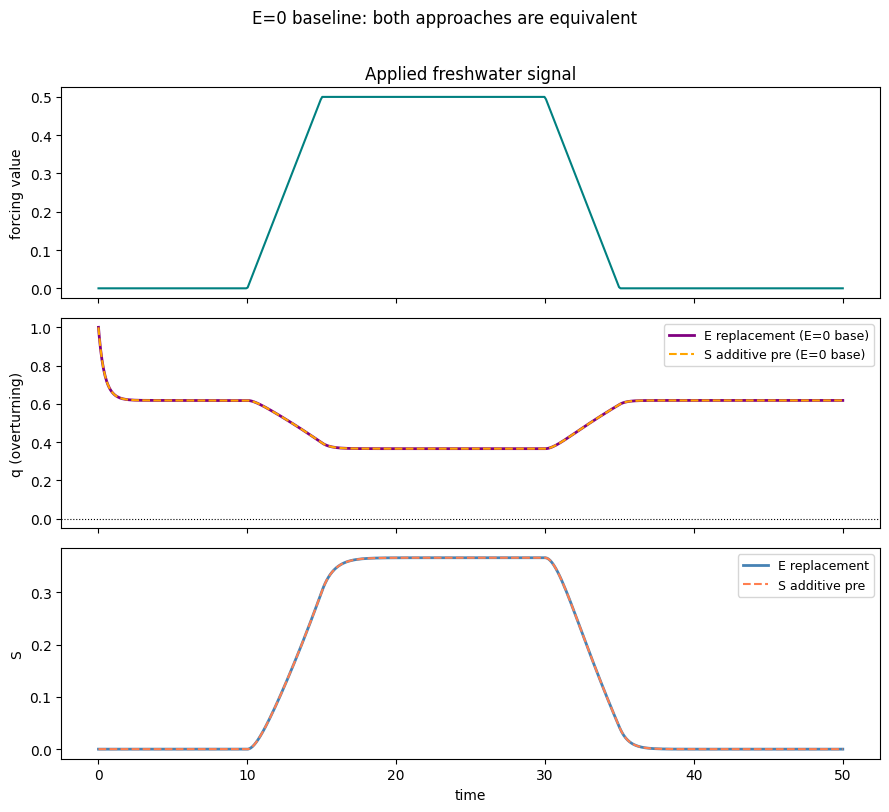

In [7]:
t_plot = np.linspace(0, 50, 500)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(t_plot, [fw_forcing.get_forcing(t) for t in t_plot], color='teal')
axes[0].set_ylabel('forcing value'); axes[0].set_title('Applied freshwater signal')

axes[1].plot(out_E.time, out_E.diagnostic_variables['q'],
             color='purple', lw=2, label='E replacement (E=0 base)')
axes[1].plot(out_S.time, out_S.diagnostic_variables['q'],
             color='orange', lw=1.5, ls='--', label='S additive pre (E=0 base)')
axes[1].axhline(0, color='k', lw=0.8, ls=':')
axes[1].set_ylabel('q (overturning)'); axes[1].legend(fontsize=9)

axes[2].plot(out_E.time, out_E.state_variables['S'],
             color='steelblue', lw=2, label='E replacement')
axes[2].plot(out_S.time, out_S.state_variables['S'],
             color='coral', lw=1.5, ls='--', label='S additive pre')
axes[2].set_ylabel('S'); axes[2].set_xlabel('time'); axes[2].legend(fontsize=9)

fig.suptitle('E=0 baseline: both approaches are equivalent', y=1.01)
plt.tight_layout(); plt.show()

**Figure.** With $E=0$ at construction, both forcing approaches are equivalent: the overturning $q$ traces are indistinguishable (top panel for E-replacement, overlapping dashes for S-additive). The freshwater pulse briefly weakens overturning; the system recovers when the pulse ends. The forcing itself is shown in the top panel for reference.

The distinction matters when there is a non-zero baseline `E`. **Parameter replacement** overrides the baseline entirely during the forced period. **Additive pre-step** superposes the forcing on top of it:

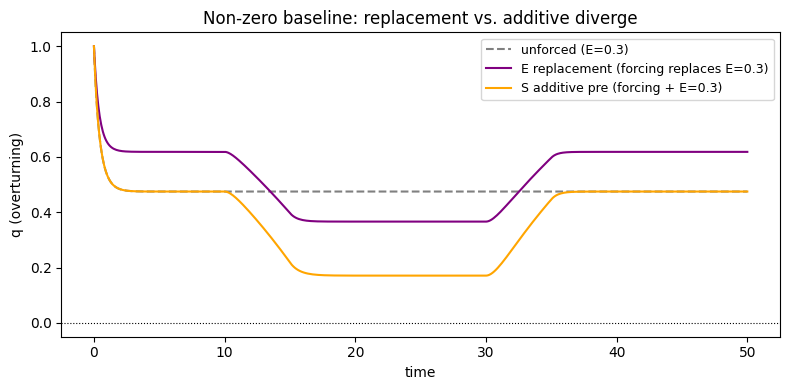

In [8]:
# E=0.3 baseline — replacement overrides it; additive adds on top
m_E_base = Stommel(E=0.3, T_star=1.0, S_star=0.0)
m_E_base.register_forcing('E', fw_forcing)          # E(t) = fw_forcing, ignoring 0.3

m_S_base = Stommel(E=0.3, T_star=1.0, S_star=0.0)
m_S_base.register_forcing('S', fw_forcing, 'additive', timing='pre')  # dS/dt gets +fw_forcing ON TOP of E=0.3

out_E_base = m_E_base.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')
out_S_base = m_S_base.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(output.time,    output.diagnostic_variables['q'],
        color='gray', ls='--', label='unforced (E=0.3)')
ax.plot(out_E_base.time, out_E_base.diagnostic_variables['q'],
        color='purple', label='E replacement (forcing replaces E=0.3)')
ax.plot(out_S_base.time, out_S_base.diagnostic_variables['q'],
        color='orange', label='S additive pre (forcing + E=0.3)')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_ylabel('q (overturning)'); ax.set_xlabel('time'); ax.legend(fontsize=9)
ax.set_title('Non-zero baseline: replacement vs. additive diverge')
plt.tight_layout(); plt.show()

**Figure.** With $E=0.3$ at construction, the two approaches diverge. E-replacement: the baseline $E=0.3$ is completely overridden — during Hold periods `E=0`, so the effective freshwater input is zero. S-additive: the forcing adds on top of the existing $E=0.3$ term in $\dot{S}$, so the total freshwater influence is $E + f(t)$. Choose the approach that matches the physical interpretation of your forcing.

**Summary of the two approaches:**

| | `register_forcing('E', ...)` | `register_forcing('S', ..., 'additive', timing='pre')` |
|--|--|--|
| Acts on | parameter `E` in `param_values` | state variable `S` via `dS/dt` |
| With non-zero `E` | replaces the baseline entirely | adds perturbation on top of baseline |
| Physical meaning | the forcing *is* the net freshwater flux | an additional flux injected into the salinity budget |
| With adaptive solver (RK45) | ✓ applied at every function evaluation | ✓ applied at every function evaluation |

> **Note on `timing='post'`:** Registering a state-variable additive forcing with `timing='post'` would add the forcing value directly to `S` after each integration step (rather than to `dS/dt`). This is not physically meaningful here and will generate a warning when used with adaptive solvers, which do not support post-step application.



## Time-evolving parameters

Any parameter in `param_values` can be a callable instead of a scalar. The dispatcher accepts `(t)`, `(t, state)`, or `(t, state, model)`. Here `E` drifts upward slowly without using a `Forcing` object:

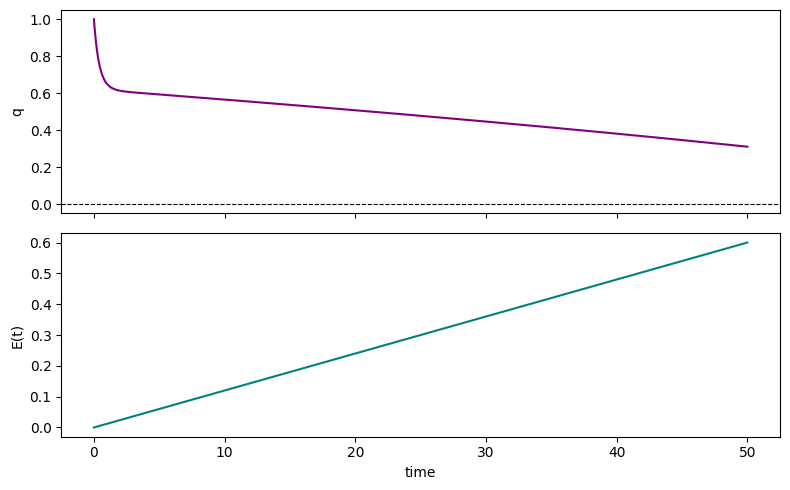

In [9]:
def E_ramp(t):
    return np.clip(0.012 * t, 0.0, 0.6)

model_ramp = Stommel(E=E_ramp, T_star=1.0, S_star=0.0)
out_ramp = model_ramp.integrate(t_span=(0, 50), y0=[1.0, 0.0], method='RK45')

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(out_ramp.time, out_ramp.diagnostic_variables['q'], color='purple')
axes[0].axhline(0, color='k', lw=0.8, ls='--'); axes[0].set_ylabel('q')
t_plot = np.linspace(0, 50, 500)
axes[1].plot(t_plot, [E_ramp(t) for t in t_plot], color='teal')
axes[1].set_ylabel('E(t)'); axes[1].set_xlabel('time')
plt.tight_layout(); plt.show()

**Figure.** Top: overturning $q$ under a linearly increasing $E$ (freshwater input). $q$ declines steadily and crosses zero around $t \approx 35$ — the circulation collapses from thermally-direct (TH mode, $q>0$) to salinity-driven (SA mode, $q<0$). Bottom: the $E(t)$ ramp used. This is the canonical Stommel bifurcation: once $q<0$, the system is in a different stable state.

## Converting to pyleoclim

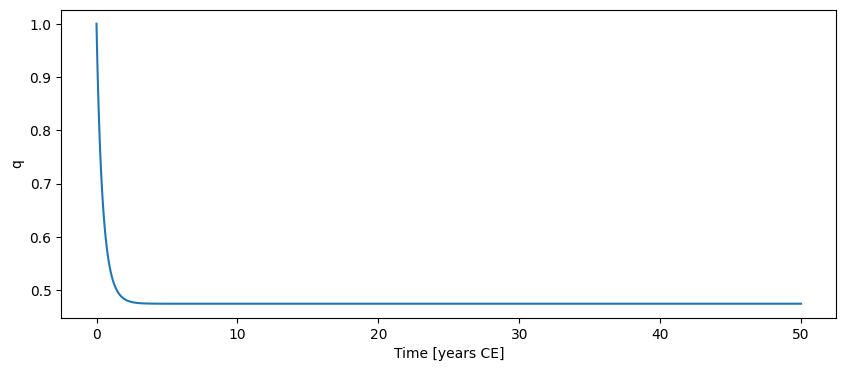

{}


In [10]:
ts_q = output.to_pyleo(var_names=['q'])
ts_q.plot()
plt.show()

## Solver notes

RK45 is appropriate for this model. Near an overturning collapse (where `q` passes through zero) the system can stiffen — tighten tolerances if trajectories look erratic:

```python
output = model.integrate(
    t_span=(0, 50), y0=[1.0, 0.0], method='RK45',
    kwargs={'rtol': 1e-8, 'atol': 1e-10},
)
```

The diagnostic `q` is computed from the full trajectory *after* integration (`uses_post_history = True`) and is not available mid-run.